In [9]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.io import loadmat
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score
from pyod.models.pca import PCA
from pyod.models.kpca import KPCA
from pyod.utils.utility import standardizer
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras import layers, Model, Sequential
from tensorflow.keras.datasets import mnist

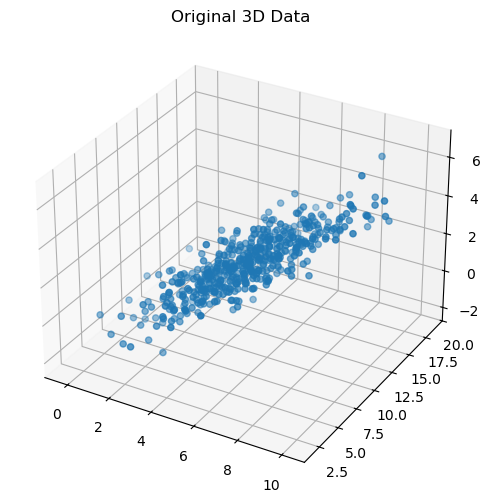

Eigenvalues: [10.20603023  3.92995978  0.37224574]
Eigenvectors:
 [[-0.3258802   0.70594351  0.62884486]
 [-0.9235264  -0.37999209 -0.05200967]
 [-0.20224018  0.59770375 -0.77578937]]


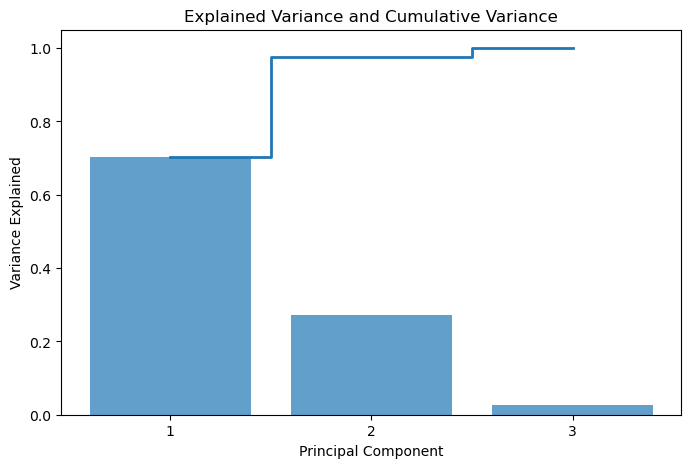

PC3 threshold: 1.0242737873346697
Number of anomalies: 50


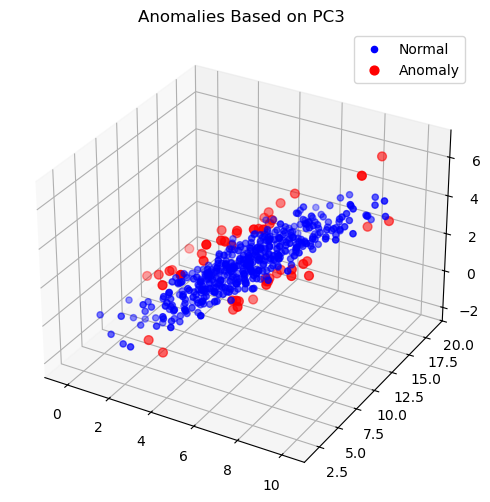

PC2 threshold: 3.2103353887735744
Number of anomalies: 50


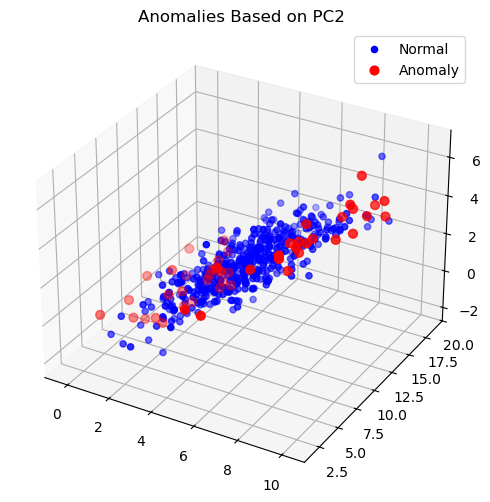

Full PCA-distance threshold: 6.534597813075915
Number of anomalies: 50


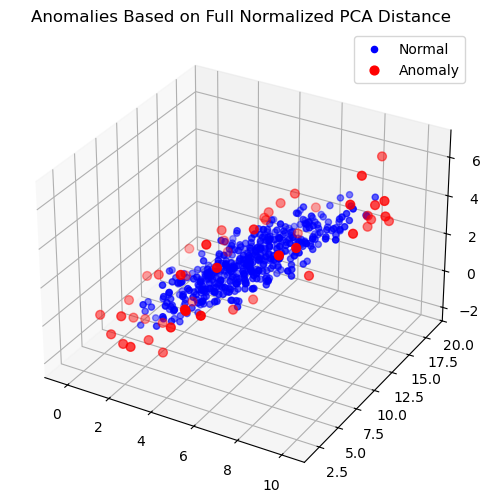

In [2]:
# Ex. 1
# 1. In the first exercise you will generate a 3D dataset with 500 points using np.random.multivariate normal
# function with the mean vector [5, 10, 2] and the covariance matrix [[3, 2, 2], [2, 10, 1], [2, 1, 2]] and
# plot it (3D). Then you will perform the PCA steps from the course (center data, compute covariance matrix, EVD).
# 2. Plot in the same figure both the cumulative explained variance (computed with the sorted [descending]
# eigenvalues and the numpy.cumsum function) with the pyplot.step function and the individual variances
# (respecting the order) - using the pyplot.bar function.
# 3. Project the data in the new space and identify the outliers based on the deviation of the values over the
# dimension corresponding to the 3rd principal component (compared to the mean of all the values of the same
# component). Use 0.1 as contamination rate and the numpy.quantile function in order to find the corresponding
# threshold and predict the labels. Plot the dataset again (using a different color for points labeled as anomalies).
# Repeat the same steps for the second principal component.
# 4. Project the data in the new space and identify the outliers based on the normalized distance (by the
# corresponding standard deviation) of the data points to the centroid (in the new space) along all the principal
# components (follow the steps from the algorithm in the first part of the lab). Plot the dataset again (using a
# different color for points labeled as anomalies)

# generating the dataset
np.random.seed(0)

mean = np.array([5, 10, 2])
cov = np.array([[3, 2, 2],
                [2, 10, 1],
                [2, 1, 2]])

n_points = 500

X = np.random.multivariate_normal(mean, cov, size=n_points)

# 3D scatter
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:,0], X[:,1], X[:,2], s=20)
ax.set_title("Original 3D Data")
plt.show()

# Center the data
X_centered = X - X.mean(axis=0)

# Compute covariance matrix
N = X_centered.shape[0]
Sigma = (X_centered.T @ X_centered) / N

# Eigen decomposition
eigvals, eigvecs = np.linalg.eigh(Sigma)

# eigh returns eigenvalues ASCENDING → reverse to descending
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

print("Eigenvalues:", eigvals)
print("Eigenvectors:\n", eigvecs)

# individual explained variance
explained = eigvals / eigvals.sum()

# cumulative
cum_explained = np.cumsum(explained)

plt.figure(figsize=(8,5))
plt.bar([1,2,3], explained, alpha=0.7)
plt.step([1,2,3], cum_explained, where="mid", linewidth=2)

plt.xlabel("Principal Component")
plt.ylabel("Variance Explained")
plt.title("Explained Variance and Cumulative Variance")
plt.xticks([1,2,3])
plt.show()

# project data into PCA space
Xp = X_centered @ eigvecs

# outliers using PC3 (the 3rd component)
pc3 = Xp[:, 2]
mean_pc3 = pc3.mean()
abs_dev_pc3 = np.abs(pc3 - mean_pc3)

contamination = 0.1
threshold_pc3 = np.quantile(abs_dev_pc3, 1 - contamination)

labels_pc3 = (abs_dev_pc3 > threshold_pc3).astype(int)

print("PC3 threshold:", threshold_pc3)
print("Number of anomalies:", labels_pc3.sum())

# plot original data color-coded by anomalies on PC3
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

normal = labels_pc3 == 0
anomalies = labels_pc3 == 1

ax.scatter(X[normal,0], X[normal,1], X[normal,2], s=20, c='blue', label='Normal')
ax.scatter(X[anomalies,0], X[anomalies,1], X[anomalies,2], s=40, c='red', label='Anomaly')

ax.set_title("Anomalies Based on PC3")
ax.legend()
plt.show()

# outliers using PC2 (2nd component)
pc2 = Xp[:, 1]
mean_pc2 = pc2.mean()
abs_dev_pc2 = np.abs(pc2 - mean_pc2)

threshold_pc2 = np.quantile(abs_dev_pc2, 1 - contamination)
labels_pc2 = (abs_dev_pc2 > threshold_pc2).astype(int)

print("PC2 threshold:", threshold_pc2)
print("Number of anomalies:", labels_pc2.sum())

# plot anomalies for PC2
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

normal = labels_pc2 == 0
anomalies = labels_pc2 == 1

ax.scatter(X[normal,0], X[normal,1], X[normal,2], s=20, c='blue', label='Normal')
ax.scatter(X[anomalies,0], X[anomalies,1], X[anomalies,2], s=40, c='red', label='Anomaly')

ax.set_title("Anomalies Based on PC2")
ax.legend()
plt.show()

# outliers using normalized PCA distance
Xp_norm = Xp / np.sqrt(eigvals)
dist = np.sum(Xp_norm**2, axis=1)

threshold_full = np.quantile(dist, 1 - contamination)
labels_full = (dist > threshold_full).astype(int)

print("Full PCA-distance threshold:", threshold_full)
print("Number of anomalies:", labels_full.sum())

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

normal = labels_full == 0
anomalies = labels_full == 1

ax.scatter(X[normal,0], X[normal,1], X[normal,2], s=20, c='blue', label='Normal')
ax.scatter(X[anomalies,0], X[anomalies,1], X[anomalies,2], s=40, c='red', label='Anomaly')

ax.set_title("Anomalies Based on Full Normalized PCA Distance")
ax.legend()
plt.show()

Dataset shape: (49097, 9)
Number of anomalies: 3511
Train size: (29458, 9)
Test size: (19639, 9)
Training contamination rate: 0.07050716274017245


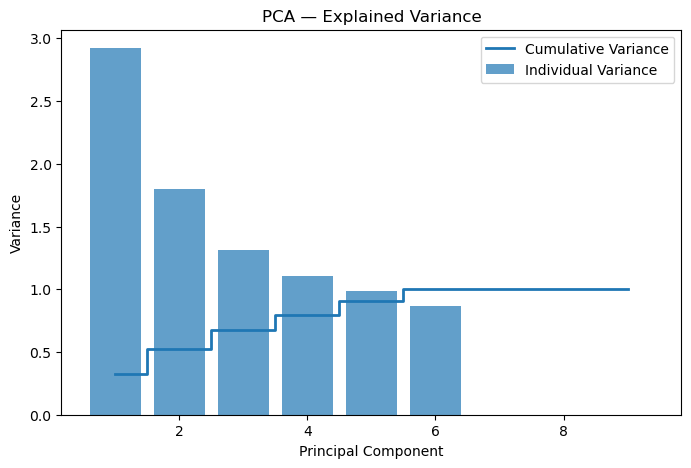

PCA Balanced Accuracy — Train: 0.9735827484194441
PCA Balanced Accuracy — Test : 0.972780593864162


In [ ]:
# Ex. 2
# 1. In this exercise you will use the shuttle dataset. Split the data in a training set and a testing set
# (60% of data). Standardize your data and fit a pyod.models.pca.PCA model with the training set using the
# real contamination rate of the training set. Plot the cumulative explained variance and the individual
# variances as in the previous exercise (you can access the variances with the explained variance attribute).
# 2. Compute the balanced accuracy for both the train and test sets. Then fit the pyod.models.kpca.KPCA model
# with the same training data and compute the scores again.

# load the shuffle dataset
data = loadmat("shuttle.mat")
X = data["X"]
y = data["y"].ravel()   # flatten to 1D vector

print("Dataset shape:", X.shape)
print("Number of anomalies:", y.sum())

# split the data in a training set and a testing set
train_data, test_data, train_labels, test_labels = train_test_split(
    X, y, train_size=0.6, random_state=0, shuffle=True
)

print("Train size:", train_data.shape)
print("Test size:", test_data.shape)

# standardize data
train_data, test_data = standardizer(train_data, test_data)

# fit a pyod PCA model with the training set using the real contamination rate of the training set
cont_rate = train_labels.mean()   # percentage of outliers in training set
print("Training contamination rate:", cont_rate)

clf_pca = PCA(contamination=cont_rate)
clf_pca.fit(train_data)

# plot the cumulative explained variance and the individual variances
ev = clf_pca.explained_variance_
cum_ev = np.cumsum(ev) / np.sum(ev)

plt.figure(figsize=(8,5))
plt.bar(range(1, len(ev)+1), ev, alpha=0.7, label="Individual Variance")
plt.step(range(1, len(ev)+1), cum_ev, where='mid', linewidth=2, label="Cumulative Variance")
plt.xlabel("Principal Component")
plt.ylabel("Variance")
plt.title("PCA — Explained Variance")
plt.legend()
plt.show()

# balanced accuracy for both the train and test sets
train_labels_pred = clf_pca.predict(train_data)
test_labels_pred = clf_pca.predict(test_data)

ba_train = balanced_accuracy_score(train_labels, train_labels_pred)
ba_test = balanced_accuracy_score(test_labels, test_labels_pred)

print("PCA Balanced Accuracy — Train:", ba_train)
print("PCA Balanced Accuracy — Test :", ba_test)

# fit the pyod KPCA model with the same training data and compute the scores again
clf_kpca = KPCA(contamination=cont_rate, kernel='rbf')
clf_kpca.fit(train_data)

train_labels_pred_k = clf_kpca.predict(train_data)
test_labels_pred_k = clf_kpca.predict(test_data)

ba_train_k = balanced_accuracy_score(train_labels, train_labels_pred_k)
ba_test_k = balanced_accuracy_score(test_labels, test_labels_pred_k)

print("\nKPCA Balanced Accuracy — Train:", ba_train_k)
print("KPCA Balanced Accuracy — Test :", ba_test_k)

Shape of X: (49097, 9)
Shape of y: (49097,)
Train / Test shapes: (24548, 9) (24549, 9)


Model: "autoencoder_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)            │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential_3 (Sequential)            │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0292 - val_loss: 0.0283
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0271 - val_loss: 0.0258
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0243 - val_loss: 0.0226
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0202 - val_loss: 0.0174
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0140 - val_loss: 0.0104
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0076 - val_loss: 0.0055
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0046 - val_loss: 0.0042
Epoch 8/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0041 - val_loss: 0.0040
Epoch 9/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0040 - val_loss: 0.0040
Epoch 10/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0040 - val_loss: 0.0040
Epoch 11/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0040 - val_loss: 0.0040
Epoch 12/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss

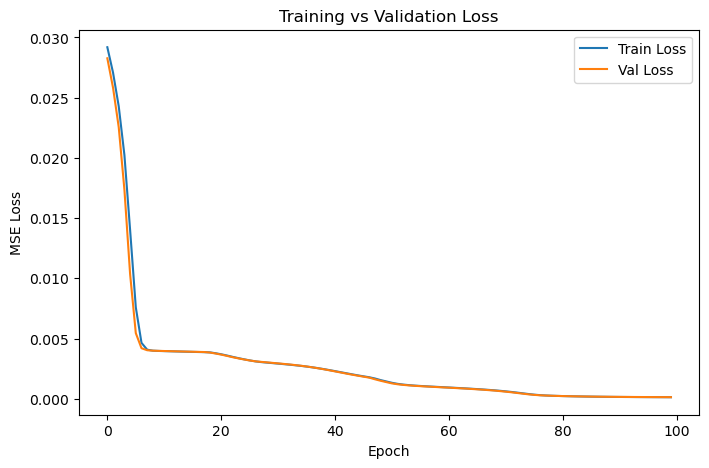

768/768 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
768/768 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Contamination rate (train): 0.07035196350008148
Threshold: 0.00031167038486892314
Balanced Accuracy (TRAIN): 0.7377767462779675
Balanced Accuracy (TEST): 0.7528291108508754


In [7]:
# Ex. 3
# For the last 2 exercises you will need to install tensorflow using pip install tensorflow.
# 1. In this exercise you will use the shuttle dataset from ODDS. Load the data using scipy.io.loadmat()
# and use train test split() to split it into train and test subsets (use 50% of data for testing). Use
# min-max normalization to bring your train data in the [0-1] range.
# 2. Design an Autoencoder class that subclasses keras.Model. Use the keras.Sequential model to create
# encoder and decoder submodels that contain only keras.layers.Dense layers. The 2 submodels should contain
# layers with [8, 5, 3] and [5, 8, 9] output units. Use relu activation function for each layer except the
# last one (from the decoder), which will use sigmoid activation.
# 3. Compile your model using adam optimizer and mse loss and fit it with your training data using 100 epochs
# and a batch size of 1024 (use the test data as validation data in the trainig process). Plot the training
# and validation loss.
# 4. In order to obtain the scores for the training data pass it through the autoencoder and get the
# reconstruction error for each sample. Compute a threshold that will be used to classify data with the
# numpy.quantile function and the contamination rate of the dataset. Compute the balanced accuracy for both
# the training and testing set.

# load the shuttle dataset
data = loadmat("shuttle.mat")
X = data["X"]
y = data["y"].astype(int).ravel()

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

# use train_test_split() to split it into train and test subsets
train_data, test_data, train_labels, test_labels = train_test_split(
    X, y, test_size=0.5, random_state=0, shuffle=True
)

# min-max normalization
scaler = MinMaxScaler()
train_data = scaler.fit_transform(train_data)
test_data  = scaler.transform(test_data)

print("Train / Test shapes:", train_data.shape, test_data.shape)

# Autoencoder class
class Autoencoder(Model):
    def __init__(self):
        super().__init__()

        # ------- ENCODER -------
        self.encoder = Sequential([
            layers.Dense(8, activation='relu'),
            layers.Dense(5, activation='relu'),
            layers.Dense(3, activation='relu'),
        ])

        # ------- DECODER -------
        self.decoder = Sequential([
            layers.Dense(5, activation='relu'),
            layers.Dense(8, activation='relu'),
            layers.Dense(9, activation='sigmoid')
        ])

    def call(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


# instantiate model
ae = Autoencoder()

# compiling using adam optimizer and mse loss
ae.compile(optimizer='adam', loss='mse')

ae.summary()

# fitting autoencoder with the training data
history = ae.fit(
    train_data,
    train_data,
    epochs=100,
    batch_size=1024,
    validation_data=(test_data, test_data),
    verbose=1
)

# plot training and validation loss
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

# reconstruction - train
train_recon = ae.predict(train_data)
train_errors = np.mean((train_data - train_recon)**2, axis=1)

# reconstruction - test
test_recon = ae.predict(test_data)
test_errors = np.mean((test_data - test_recon)**2, axis=1)

# compute threshold using contamination rate
contamination = np.mean(train_labels == 1)
print("Contamination rate (train):", contamination)

threshold = np.quantile(train_errors, 1 - contamination)
print("Threshold:", threshold)

# predict anomaly labels
train_labels_pred = (train_errors > threshold).astype(int)
test_labels_pred  = (test_errors  > threshold).astype(int)

# balanced accuracy on train and test
ba_train = balanced_accuracy_score(train_labels, train_labels_pred)
ba_test  = balanced_accuracy_score(test_labels, test_labels_pred)

print("Balanced Accuracy (TRAIN):", ba_train)
print("Balanced Accuracy (TEST):", ba_test)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - loss: 0.0346 - val_loss: 0.0067
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 0.0060 - val_loss: 0.0052
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 0.0050 - val_loss: 0.0046
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - loss: 0.0045 - val_loss: 0.0042
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 0.0042 - val_loss: 0.0039
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 0.0040 - val_loss: 0.0038
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 0.0038 - val_loss: 0.0036
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 0.0037 - val_loss: 0.0035
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - loss: 0.0036 - val_loss: 0.0035
Epoch 10/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.0036 - val_loss: 0.0034


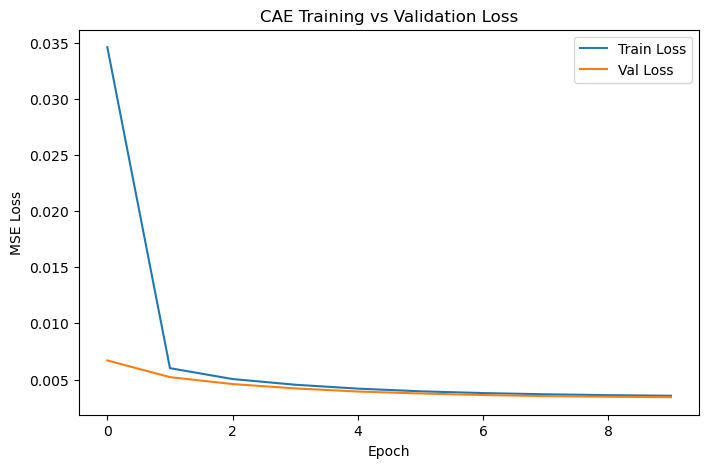

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step
Reconstruction threshold: 0.00540768
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy on original test images: 0.8799
Accuracy on noisy test images: 1.0


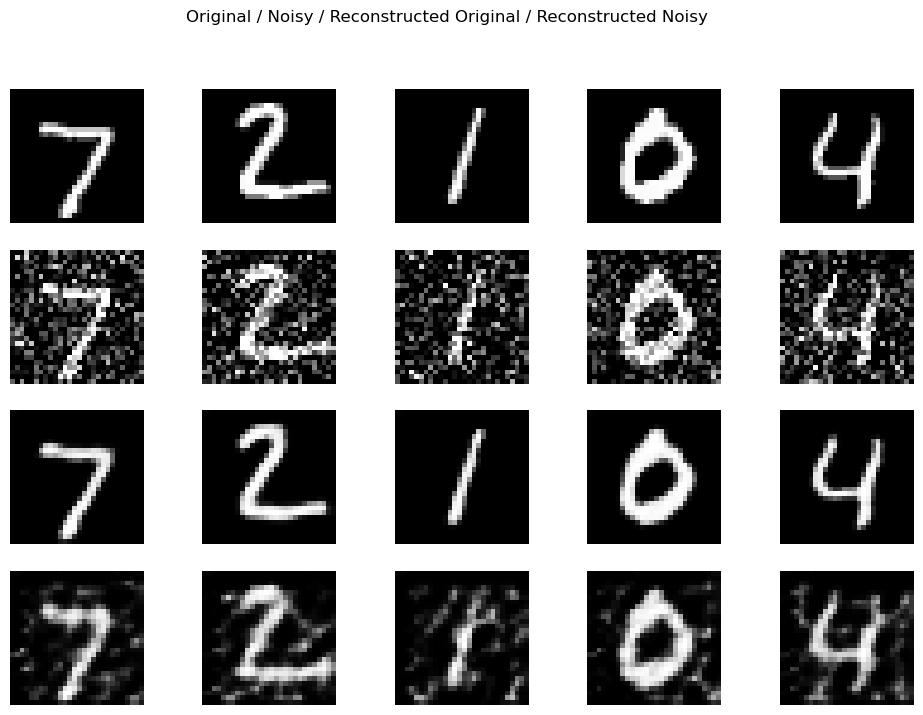

In [11]:
# Ex. 4
# 1. In this exercise we will use the mnist dataset from tensorflow.keras.datasets.mnist. After you load the
# dataset with tensorflow.keras.datasets.mnist.load data() you will normalize it by dividing with 255. In
# order to simulate anomalies, you will add some noise to the images with tensorflow.random.normal (multiplied
# by a factor of 0.35). You will use tensorflow.clip by value to keep the range of the pixels [0, 1].
# 2. Design a Convolutional Autoencoder class that uses the keras.Sequential model to create encoder and decoder
# submodels that contain keras.layers.Conv2D and keras.layers.Conv2DTranspose layers. The encoder will contain:
# • 1 Conv2D layer with 8 (3 X 3) filters, relu activation, strides=2 and padding - ’same’
# • 1 Conv2D layer with 4 (3 X 3) filters and the rest of params as above
# The decoder will consist of:
# • 1 Conv2DTranspose layer with the same parameters as the last layer of the encoder
# • 1 Conv2DTranspose layer with the same parameters as the first layer of the encoder
# • 1 Conv2D layer with 1 filter with sigmoid activation that will reconstruct the original image
# 3. Compile your model using adam optimizer and mse loss and fit it with
# your training data using 10 epochs and a batch size of 64 (use the test data as validation data in the trainig
# process). Use only the original train data for training. Compute the reconstruction loss for the training
# data and a threshold (that will be the mean of the reconstruction errors + their standard deviation). Based
# on the threshold and the obtained reconstruction errors classify both the original test images and the ones
# that have the added noise (and compute the corresponding accuracy).
# 4. Plot in the same figure, on four rows, 5 test images: on the first row - the original ones, on the second
# one - the images with the added noise, on the third, the reconstructed images obtained from the original ones
# and on the last row the reconstructed images obtained from the images with added noise.
# 5. Modify the training stage in order to obtain a Denoising Autoencoder and print the same figure again.

# load the mnist dataset
(train_data, _), (test_data, _) = mnist.load_data()

# normalize to [0, 1] and add channel dimension
train_data = train_data.astype("float32") / 255.
test_data = test_data.astype("float32") / 255.
train_data = np.expand_dims(train_data, -1)
test_data = np.expand_dims(test_data, -1)

# add noise to simulate anomalies
noise_factor = 0.35
noisy_test_data = test_data + noise_factor * tf.random.normal(shape=test_data.shape)
noisy_test_data = tf.clip_by_value(noisy_test_data, 0., 1.)

# Convolutional Autoencoder class
class ConvAutoencoder(Model):
    def __init__(self):
        super().__init__()

        # ------- Encoder -------
        self.encoder = Sequential([
            layers.Conv2D(8, (3,3), activation='relu', strides=2, padding='same'),
            layers.Conv2D(4, (3,3), activation='relu', strides=2, padding='same')
        ])

        # ------- Decoder -------
        self.decoder = Sequential([
            layers.Conv2DTranspose(4, (3,3), activation='relu', strides=2, padding='same'),
            layers.Conv2DTranspose(8, (3,3), activation='relu', strides=2, padding='same'),
            layers.Conv2D(1, (3,3), activation='sigmoid', padding='same')
        ])

    def call(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

cae = ConvAutoencoder()

# compile model using adam optimizer and mse loss
cae.compile(optimizer='adam', loss='mse')

# fitting it with the training data
history = cae.fit(
    train_data, train_data,
    epochs=10,
    batch_size=64,
    validation_data=(test_data, test_data)
)

# plot training and validation loss
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("CAE Training vs Validation Loss")
plt.legend()
plt.show()

# reconstruct training images
train_recon = cae.predict(train_data)
train_errors = np.mean(np.square(train_data - train_recon), axis=(1,2,3))

# threshold = mean + std
threshold = train_errors.mean() + train_errors.std()
print("Reconstruction threshold:", threshold)

# reconstruct test images (original and noisy)
test_recon = cae.predict(test_data)
test_noisy_recon = cae.predict(noisy_test_data)

# compute reconstruction error for test and noisy images
test_errors = np.mean(np.square(test_data - test_recon), axis=(1,2,3))
test_noisy_errors = np.mean(np.square(noisy_test_data - test_noisy_recon), axis=(1,2,3))

# classify based on threshold
test_labels_pred = (test_errors > threshold).astype(int)
test_noisy_labels_pred = (test_noisy_errors > threshold).astype(int)

# accuracy
acc_test = np.mean(test_labels_pred == 0)
acc_noisy = np.mean(test_noisy_labels_pred == 1)

print("Accuracy on original test images:", acc_test)
print("Accuracy on noisy test images:", acc_noisy)

n = 5
plt.figure(figsize=(12,8))

for i in range(n):
    # original
    ax = plt.subplot(4, n, i+1)
    plt.imshow(test_data[i].squeeze(), cmap='gray')
    plt.axis('off')
    
    # noisy
    ax = plt.subplot(4, n, i+1+n)
    plt.imshow(noisy_test_data[i].numpy().squeeze(), cmap='gray')
    plt.axis('off')
    
    # reconstructed original
    ax = plt.subplot(4, n, i+1+2*n)
    plt.imshow(test_recon[i].squeeze(), cmap='gray')
    plt.axis('off')
    
    # reconstructed noisy
    ax = plt.subplot(4, n, i+1+3*n)
    plt.imshow(test_noisy_recon[i].squeeze(), cmap='gray')
    plt.axis('off')

plt.suptitle("Original / Noisy / Reconstructed Original / Reconstructed Noisy")
plt.show()


Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 0.0525 - val_loss: 0.0137
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.0112 - val_loss: 0.0103
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.0100 - val_loss: 0.0096
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.0097 - val_loss: 0.0094
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.0095 - val_loss: 0.0092
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.0093 - val_loss: 0.0091
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 0.0092 - val_loss: 0.0091
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 0.0090 - val_loss: 0.0089
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 0.0089 - val_loss: 0.0091
Epoch 10/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 0.0088 - val_loss: 0.0088
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


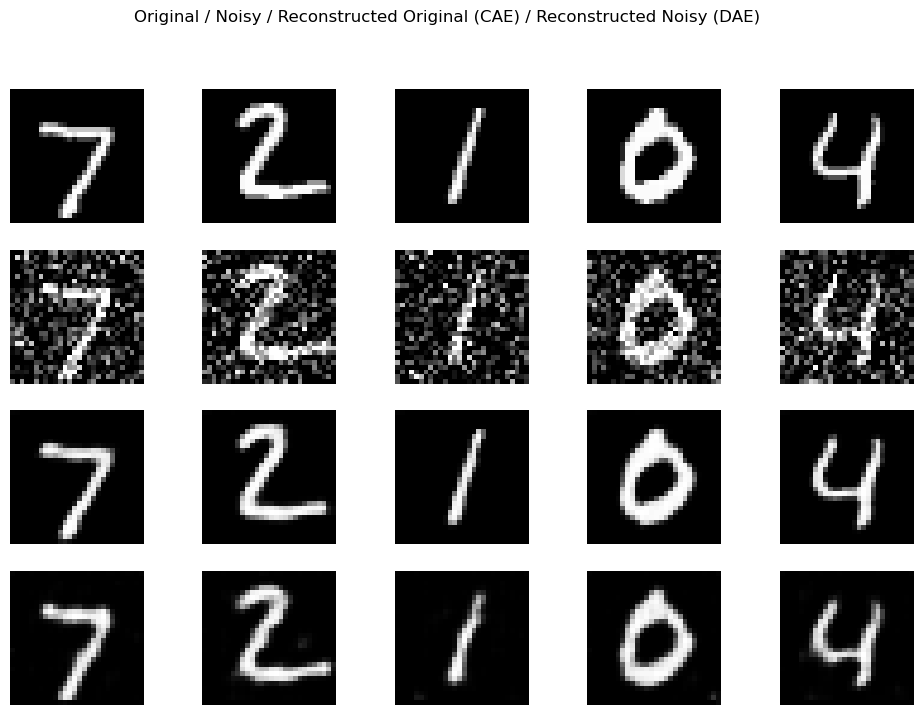

In [13]:
# modify the training stage in order to obtain a Denoising Autoencoder and print the same figure again
dae = ConvAutoencoder()
dae.compile(optimizer='adam', loss='mse')

history_dae = dae.fit(
    train_data + 0.35 * tf.random.normal(train_data.shape),
    train_data,
    epochs=10,
    batch_size=64,
    validation_data=(noisy_test_data, test_data)
)

# reconstruct noisy test images
dae_noisy_recon = dae.predict(noisy_test_data)

# plot results
plt.figure(figsize=(12,8))

for i in range(n):
    # original
    plt.subplot(4, n, i+1)
    plt.imshow(test_data[i].squeeze(), cmap='gray')
    plt.axis('off')
    
    # noisy
    plt.subplot(4, n, i+1+n)
    plt.imshow(noisy_test_data[i].numpy().squeeze(), cmap='gray')
    plt.axis('off')
    
    # reconstructed original (CAE)
    plt.subplot(4, n, i+1+2*n)
    plt.imshow(test_recon[i].squeeze(), cmap='gray')
    plt.axis('off')
    
    # reconstructed noisy (DAE)
    plt.subplot(4, n, i+1+3*n)
    plt.imshow(dae_noisy_recon[i].squeeze(), cmap='gray')
    plt.axis('off')

plt.suptitle("Original / Noisy / Reconstructed Original (CAE) / Reconstructed Noisy (DAE)")
plt.show()
